# Visualize Calorimeter Hit-Level Data

This notebook demonstrates how to visualize calorimeter hit data from:
1. ROOT files (raw format from simulation)
2. Parquet files (processed format for ML)

## Imports and Setup

In [1]:
%matplotlib inline

from pathlib import Path
import uproot
import awkward as ak
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import matplotlib.pyplot as plt

### set plot resolution
%config InlineBackend.figure_format = 'retina'

### set default figure parameters
plt.rcParams['figure.figsize'] = (9,6)

medium_size = 12
large_size = 15

plt.rc('font', size=medium_size)          # default text sizes
plt.rc('xtick', labelsize=medium_size)    # xtick labels
plt.rc('ytick', labelsize=medium_size)    # ytick labels
plt.rc('legend', fontsize=medium_size)    # legend
plt.rc('axes', titlesize=large_size)      # axes title
plt.rc('axes', labelsize=large_size)      # x and y labels
plt.rc('figure', titlesize=large_size)    # figure title

In [2]:
# Configuration - modify these paths as needed
ROOT_FILE = Path("/global/cfs/cdirs/m3246/mpettee/hep/particlemind/data/raw/p8_ee_tt_ecm365/root/reco_p8_ee_tt_ecm365_60000.root")
PARQUET_FILE = Path("/global/cfs/cdirs/m3246/mpettee/hep/particlemind/data/processed/p8_ee_tt_ecm365/reco_p8_ee_tt_ecm365_60000.parquet")

# Output directory for saved plots
OUTPUT_DIR = Path("./plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# Event index to visualize
EVENT_IDX = 0

In [3]:
# Subdetector configuration
SUBDETECTOR_LABELS = {
    0: "ECAL",
    1: "HCAL",
    2: "MUON"
}

SUBDETECTOR_COLORS = {
    0: "steelblue",
    1: "green",
    2: "orange"
}

# Calorimeter collections in ROOT files
CALO_COLLECTIONS = [
    "ECALBarrel",
    "ECALEndcap",
    "HCALBarrel",
    "HCALEndcap",
    "HCALOther",
    "MUON"
]

# Map collection names to subdetector codes
COLLECTION_TO_SUBDETECTOR = {
    "ECALBarrel": 0,
    "ECALEndcap": 0,
    "HCALBarrel": 1,
    "HCALEndcap": 1,
    "HCALOther": 1,
    "MUON": 2
}

## Helper Functions

In [18]:
def plot_3d_calo_hits(df, title="Calorimeter Hits 3D View", save_path=None):
    """Create interactive 3D scatter plot of calorimeter hits using Plotly."""
    traces = []

    for subdet_code, label in SUBDETECTOR_LABELS.items():
        mask = df["subdetector"] == subdet_code
        if mask.sum() == 0:
            continue

        subset = df[mask]
        # Scale marker size by energy with log scaling
        sizes = np.clip(2 + 2 * np.log1p(subset["energy"] * 1000), 1, 15)

        trace = go.Scatter3d(
            x=subset["x"],
            y=subset["y"],
            z=subset["z"],
            mode="markers",
            marker=dict(
                size=sizes,
                color=SUBDETECTOR_COLORS[subdet_code],
                opacity=0.7,
                line_width=0
            ),
            name=f"{label} ({mask.sum()} hits)",
            hovertemplate=f"{label}<br>x: %{{x:.1f}}<br>y: %{{y:.1f}}<br>z: %{{z:.1f}}<br>E: %{{customdata:.4f}} GeV",
            customdata=subset["energy"]
        )
        traces.append(trace)

    layout = go.Layout(
        title=title,
        scene=dict(
            xaxis=dict(title="X [mm]"),
            yaxis=dict(title="Y [mm]"),
            zaxis=dict(title="Z [mm]"),
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.0)
            ),
            aspectmode="data"
        ),
        legend=dict(x=0.8, y=0.9),
        width=800,
        height=700
    )

    fig = go.Figure(data=traces, layout=layout)

    if save_path:
        if str(save_path).endswith('.html'):
            fig.write_html(save_path)
        else:
            fig.write_image(save_path, scale=2)
        print(f"Saved: {save_path}")

    return fig

def plot_2d_projections(df, title_prefix="", save_path=None):
    """Create 2D projection plots (X-Y, X-Z, Y-Z) using Matplotlib."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        ("x", "y", "X-Y Projection (Beam View)"),
        ("x", "z", "X-Z Projection (Side View)"),
        ("y", "z", "Y-Z Projection (Side View)")
    ]

    for ax, (col_x, col_y, proj_title) in zip(axes, projections):
        for subdet_code, label in SUBDETECTOR_LABELS.items():
            mask = df["subdetector"] == subdet_code
            if mask.sum() == 0:
                continue
            subset = df[mask]
            ax.scatter(
                subset[col_x], subset[col_y],
                c=SUBDETECTOR_COLORS[subdet_code],
                s=1, alpha=0.5, label=label
            )

        ax.set_xlabel(f"{col_x.upper()} [mm]")
        ax.set_ylabel(f"{col_y.upper()} [mm]")
        ax.set_title(proj_title)
        ax.set_aspect("equal")
        ax.legend(loc="upper right", markerscale=5)

    fig.suptitle(f"{title_prefix} 2D Projections", fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

def plot_energy_distribution(df, title_prefix="", save_path=None):
    """Create histogram of hit energies by subdetector."""
    fig, ax = plt.subplots(figsize=(10, 6))

    # Compute common bin edges from all energies
    all_energies = df["energy"]
    bins = np.linspace(all_energies.min(), all_energies.max(), 51)

    for subdet_code, label in SUBDETECTOR_LABELS.items():
        mask = df["subdetector"] == subdet_code
        if mask.sum() == 0:
            continue
        energies = df.loc[mask, "energy"]
        ax.hist(
            energies, bins=bins, alpha=0.7,
            color=SUBDETECTOR_COLORS[subdet_code],
            label=f"{label} (n={mask.sum()})",
            histtype="stepfilled", edgecolor="black", linewidth=0.5
        )

    ax.set_xlabel("Energy [GeV]")
    ax.set_ylabel("Number of Hits")
    ax.set_title(f"{title_prefix} Hit Energy Distribution")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

def plot_hit_counts(df, title_prefix="", save_path=None):
    """Create bar chart of hit counts per subdetector."""
    fig, ax = plt.subplots(figsize=(8, 5))

    counts = []
    labels = []
    colors = []

    for subdet_code, label in SUBDETECTOR_LABELS.items():
        count = (df["subdetector"] == subdet_code).sum()
        counts.append(count)
        labels.append(label)
        colors.append(SUBDETECTOR_COLORS[subdet_code])

    bars = ax.bar(labels, counts, color=colors, edgecolor="black", linewidth=0.5)

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}", ha="center", va="bottom", fontsize=11
        )

    ax.set_xlabel("Subdetector")
    ax.set_ylabel("Number of Hits")
    ax.set_title(f"{title_prefix} Hit Counts by Subdetector\n(Total: {sum(counts):,} hits)")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

---
# ROOT File Visualization

## Load Data from ROOT File

In [5]:
# Open ROOT file
fi = uproot.open(ROOT_FILE)
ev = fi["events"]

print(f"Loaded ROOT file: {ROOT_FILE.name}")
print(f"Number of events: {ev.num_entries}")

Loaded ROOT file: reco_p8_ee_tt_ecm365_60000.root
Number of events: 100


In [6]:
# Extract calorimeter hit data from all collections
root_hits = []

for coll in CALO_COLLECTIONS:
    # Read hit data for this collection
    x = ev[f"{coll}/{coll}.position.x"].array()[EVENT_IDX]
    y = ev[f"{coll}/{coll}.position.y"].array()[EVENT_IDX]
    z = ev[f"{coll}/{coll}.position.z"].array()[EVENT_IDX]
    energy = ev[f"{coll}/{coll}.energy"].array()[EVENT_IDX]
    
    n_hits = len(x)
    if n_hits > 0:
        coll_df = pd.DataFrame({
            "x": ak.to_numpy(x),
            "y": ak.to_numpy(y),
            "z": ak.to_numpy(z),
            "energy": ak.to_numpy(energy),
            "subdetector": np.full(n_hits, COLLECTION_TO_SUBDETECTOR[coll]),
            "collection": coll
        })
        root_hits.append(coll_df)
        print(f"{coll}: {n_hits} hits")

# Combine all hits into single DataFrame
df_root = pd.concat(root_hits, ignore_index=True)
print(f"\nTotal calorimeter hits: {len(df_root):,}")

ECALBarrel: 6917 hits
ECALEndcap: 1277 hits
HCALBarrel: 1423 hits
HCALEndcap: 162 hits
HCALOther: 40 hits
MUON: 18 hits

Total calorimeter hits: 9,837


## 3D Scatter Plot

In [19]:
plot_3d_calo_hits(
    df_root,
    title=f"ROOT: Calorimeter Hits (Event {EVENT_IDX})",
    save_path=OUTPUT_DIR / f"root_3d_event{EVENT_IDX}.html"
)

Saved: plots/root_3d_event0.html


## 2D Projections

Saved: plots/root_2d_projections_event0.png


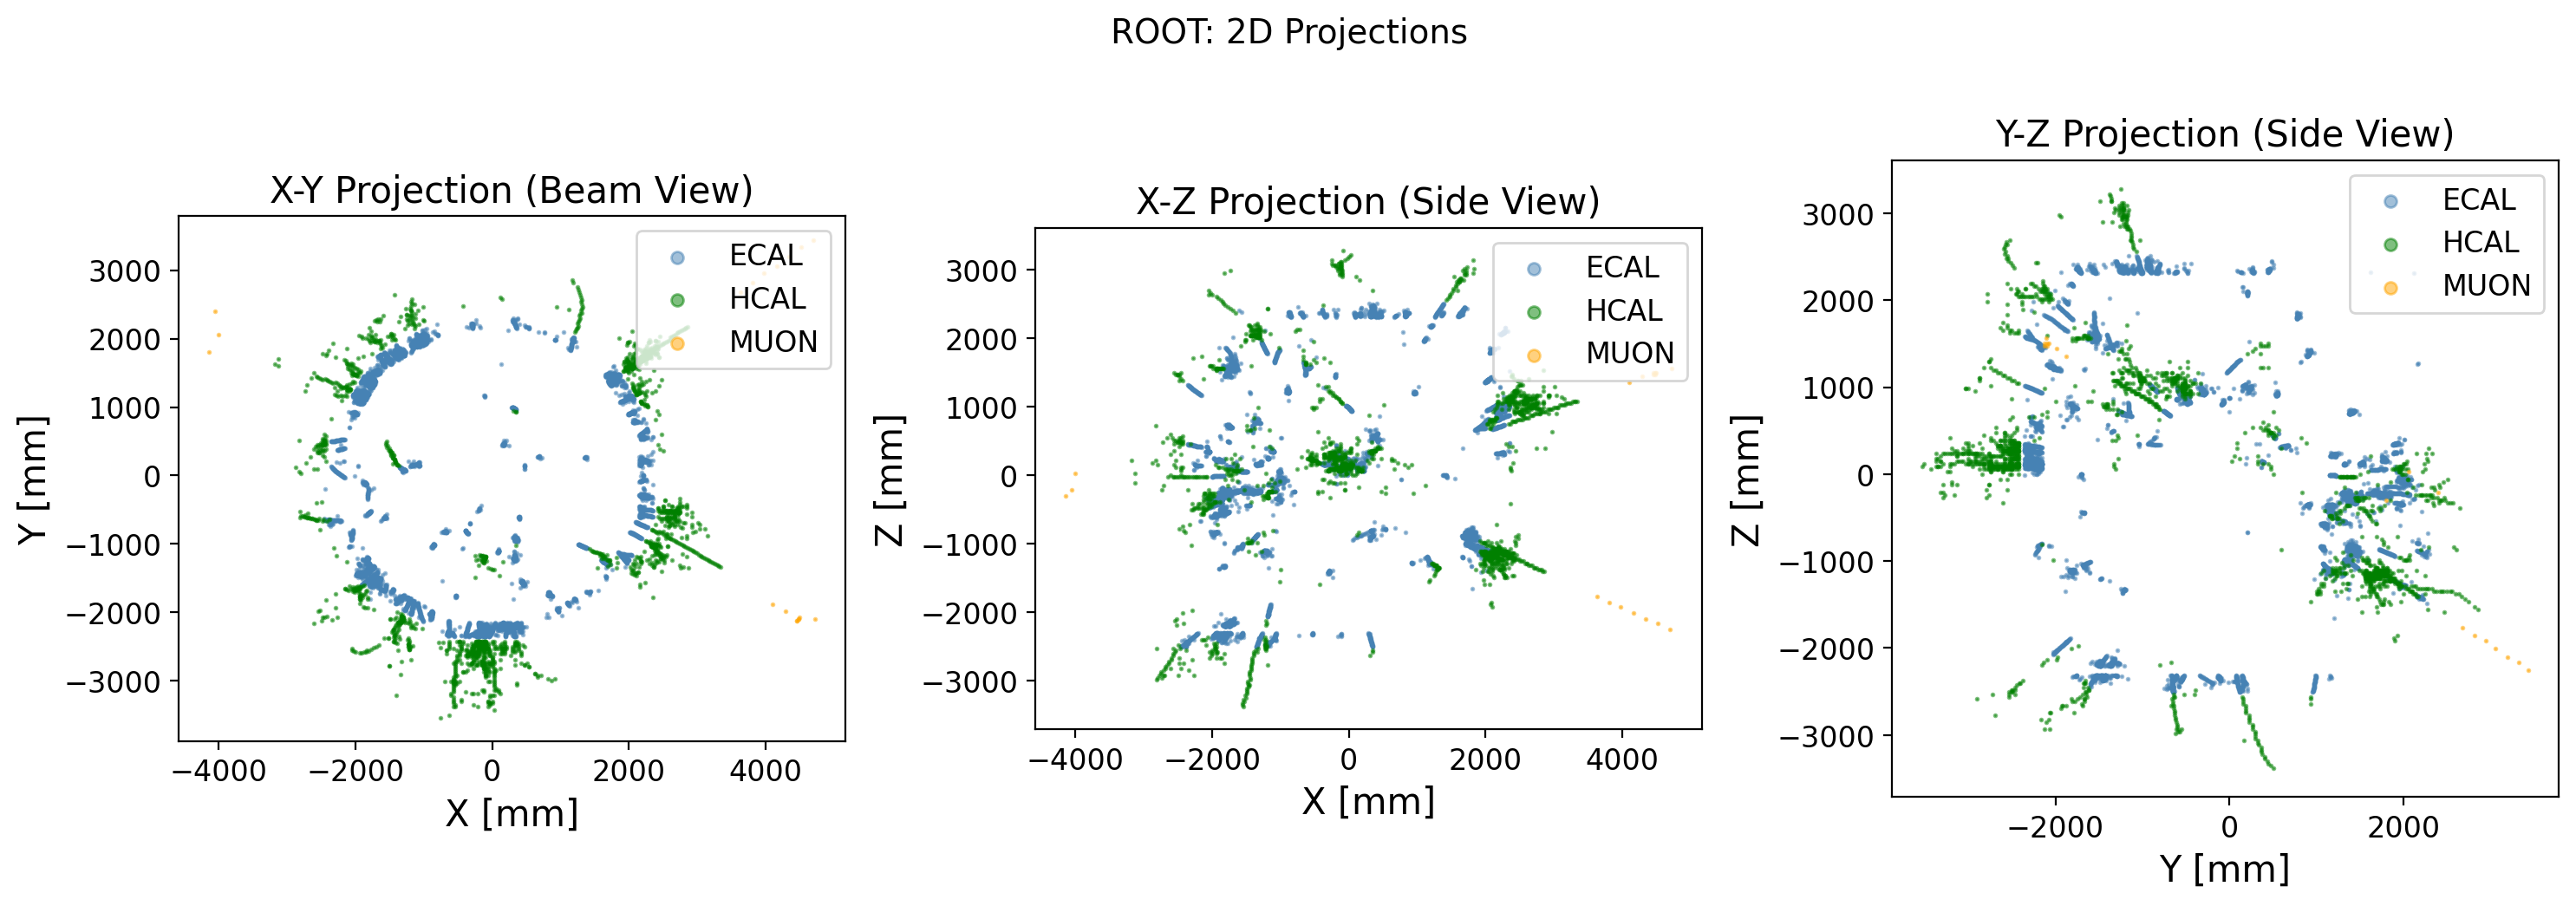

In [8]:
plot_2d_projections(
    df_root,
    title_prefix="ROOT:",
    save_path=OUTPUT_DIR / f"root_2d_projections_event{EVENT_IDX}.png"
)

## Energy Distribution

Saved: plots/root_energy_dist_event0.png


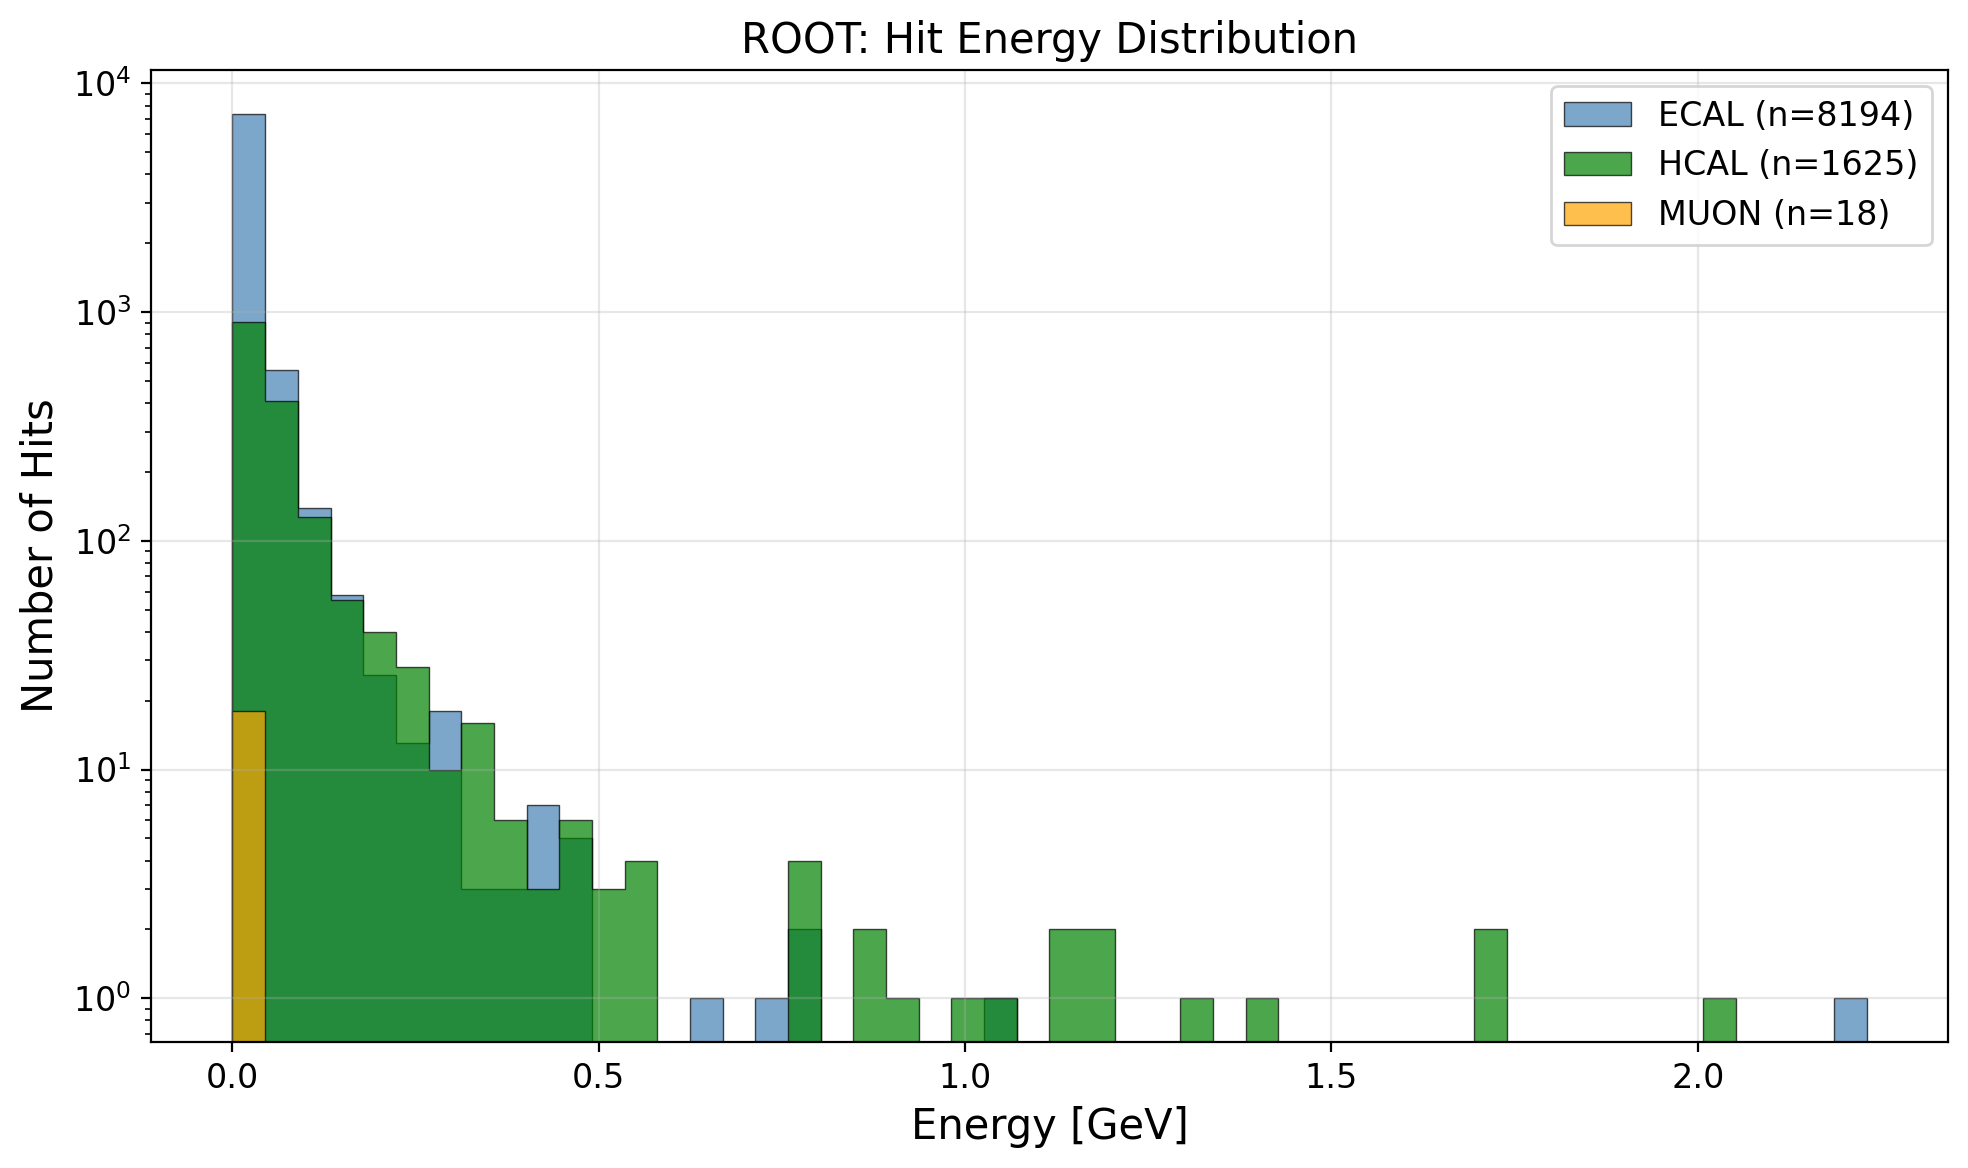

In [9]:
plot_energy_distribution(
    df_root,
    title_prefix="ROOT:",
    save_path=OUTPUT_DIR / f"root_energy_dist_event{EVENT_IDX}.png"
)

## Hit Count Statistics

Saved: plots/root_hit_counts_event0.png


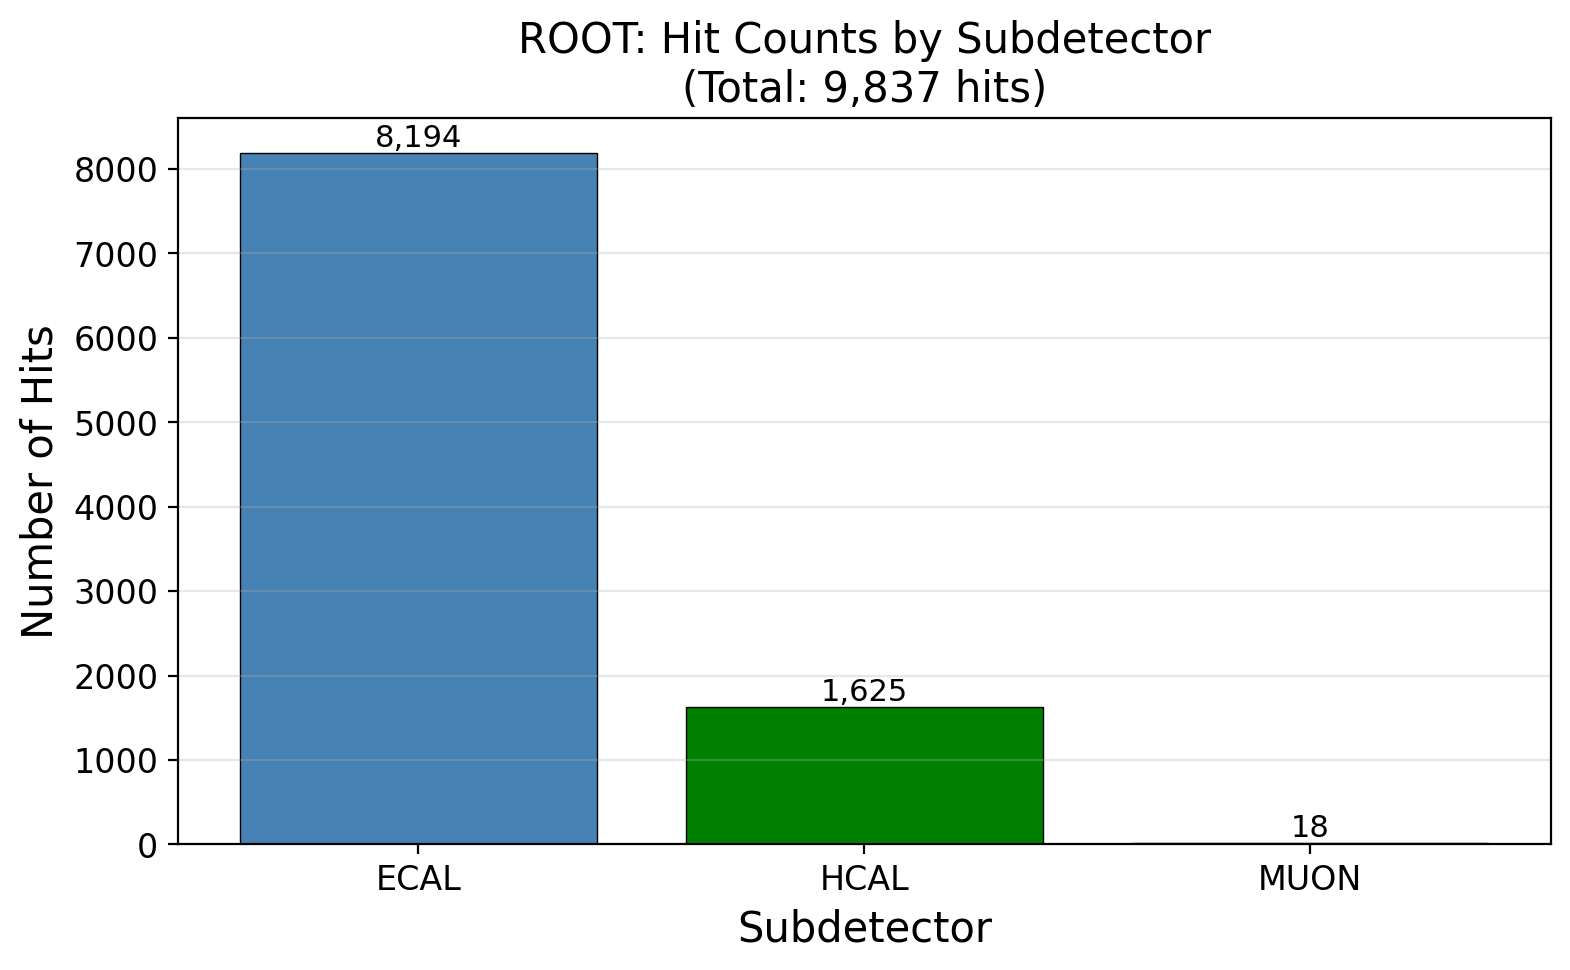

In [10]:
plot_hit_counts(
    df_root,
    title_prefix="ROOT:",
    save_path=OUTPUT_DIR / f"root_hit_counts_event{EVENT_IDX}.png"
)

---
# Parquet File Visualization

## Load Data from Parquet File

In [11]:
# Load parquet file
data = ak.from_parquet(PARQUET_FILE)

print(f"Loaded Parquet file: {PARQUET_FILE.name}")
print(f"Available fields: {data.fields}")

# Check number of events (handle both Array and Record types)
if hasattr(data, '__len__'):
    n_events = len(data)
else:
    # Data is a Record - check length of first field
    first_field = data.fields[0]
    n_events = len(data[first_field])
print(f"Number of events: {n_events}")

Loaded Parquet file: reco_p8_ee_tt_ecm365_60000.parquet
Available fields: ['gen_features', 'track_features', 'cluster_features', 'calo_hit_features', 'tracker_hit_features', 'genparticle_to_calo_hit_matrix', 'genparticle_to_tracker_hit_matrix', 'track_to_tracker_hit_matrix', 'cluster_to_cluster_hit_matrix', 'gp_to_track_matrix', 'gp_to_gp']
Number of events: 100


In [12]:
# Extract calorimeter hit features for the selected event
# The parquet structure has calo_hit_features as an array of events
calo_hits = data["calo_hit_features"][EVENT_IDX]

print(f"Calo hit fields: {calo_hits.fields}")

# Convert to DataFrame
df_parquet = pd.DataFrame({
    "x": ak.to_numpy(calo_hits["position.x"]),
    "y": ak.to_numpy(calo_hits["position.y"]),
    "z": ak.to_numpy(calo_hits["position.z"]),
    "energy": ak.to_numpy(calo_hits["energy"]),
    "subdetector": ak.to_numpy(calo_hits["subdetector"])
})

print(f"\nTotal calorimeter hits: {len(df_parquet):,}")
print(f"\nHits per subdetector:")
for subdet_code, label in SUBDETECTOR_LABELS.items():
    count = (df_parquet["subdetector"] == subdet_code).sum()
    print(f"  {label}: {count:,}")

Calo hit fields: ['type', 'energy', 'position.x', 'position.y', 'position.z', 'subdetector']

Total calorimeter hits: 9,837

Hits per subdetector:
  ECAL: 8,194
  HCAL: 1,625
  MUON: 18


## 3D Scatter Plot

In [13]:
plot_3d_calo_hits(
    df_parquet,
    title=f"Parquet: Calorimeter Hits (Event {EVENT_IDX})",
    save_path=OUTPUT_DIR / f"parquet_3d_event{EVENT_IDX}.html"
)

Saved: plots/parquet_3d_event0.html


## 2D Projections

Saved: plots/parquet_2d_projections_event0.png


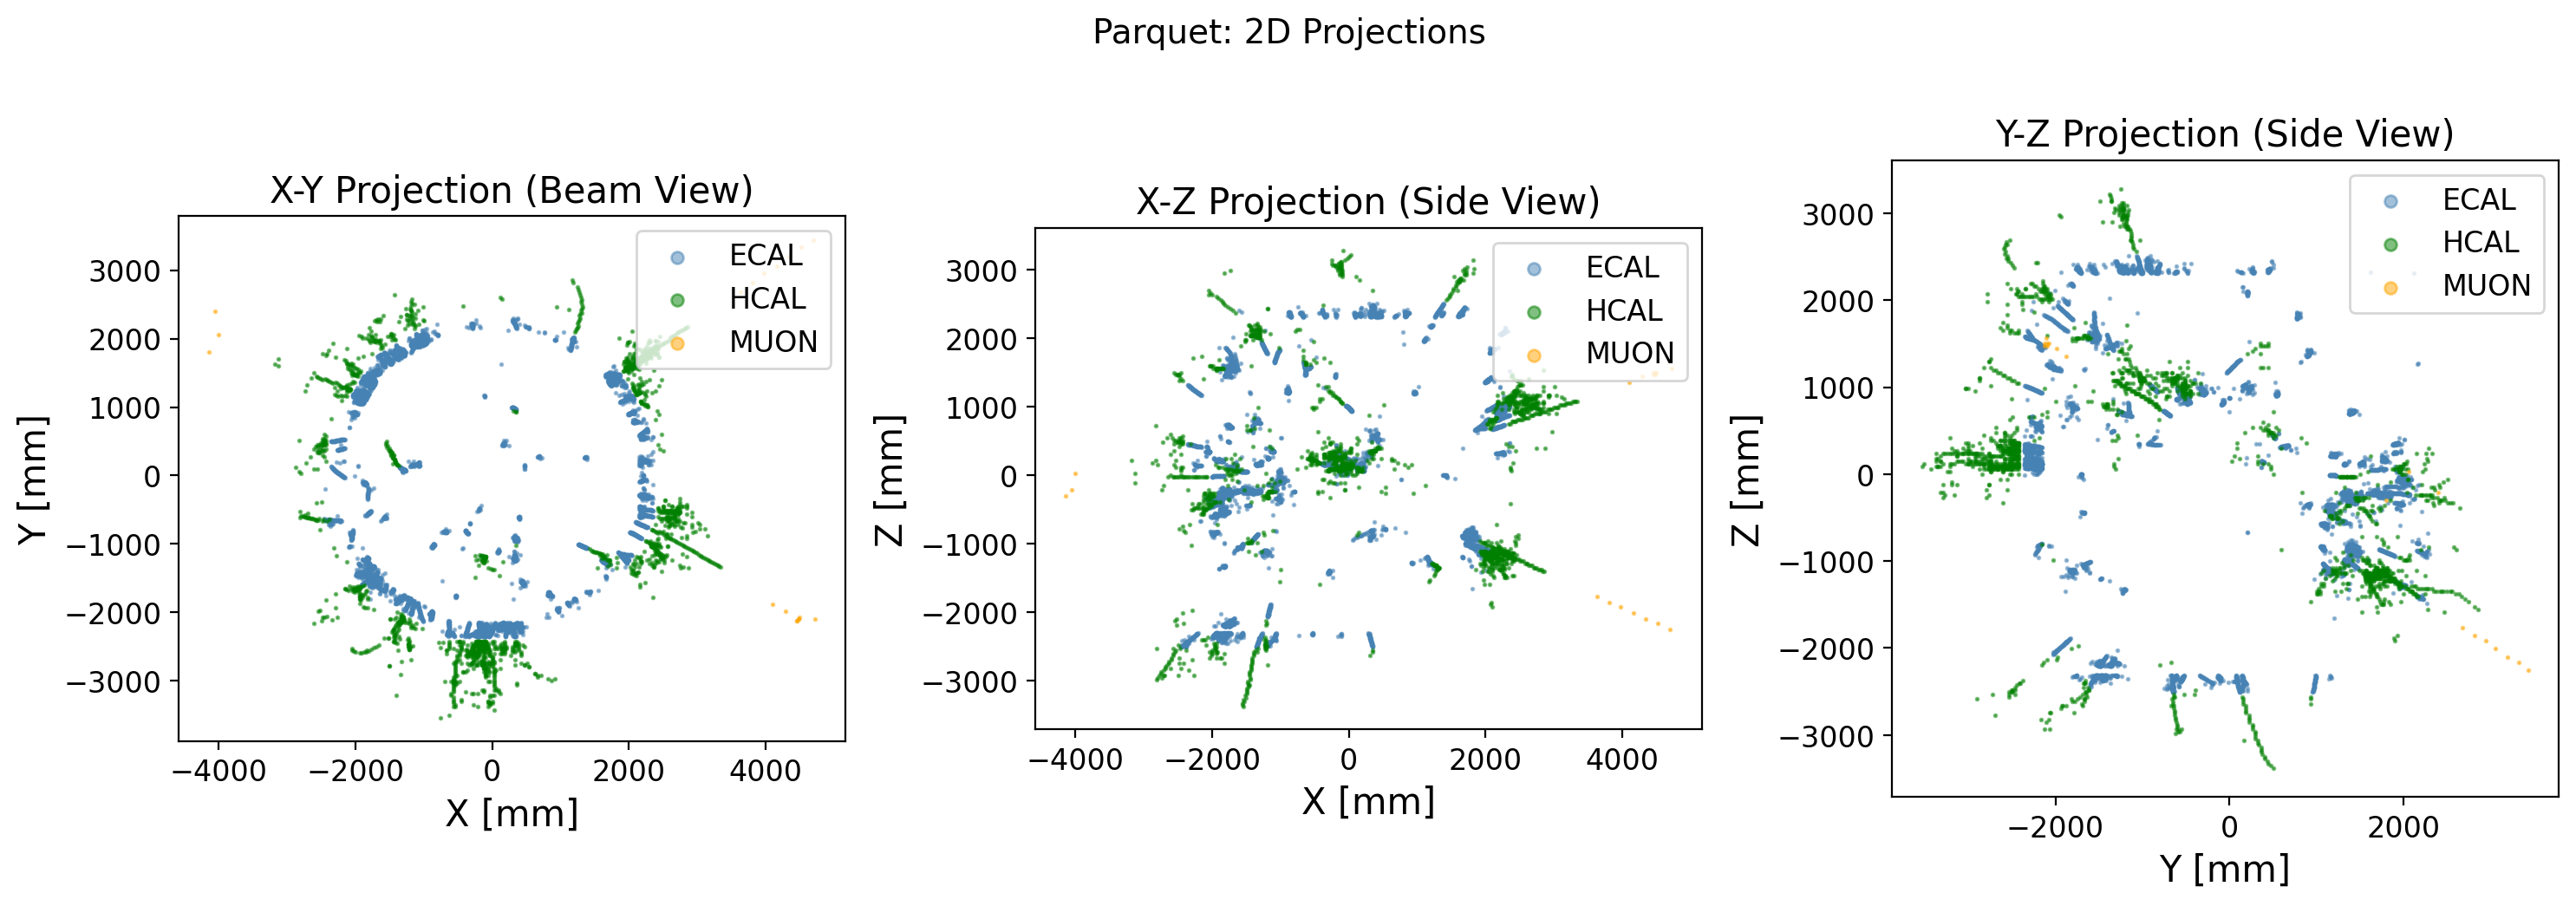

In [14]:
plot_2d_projections(
    df_parquet,
    title_prefix="Parquet:",
    save_path=OUTPUT_DIR / f"parquet_2d_projections_event{EVENT_IDX}.png"
)

## Energy Distribution

Saved: plots/parquet_energy_dist_event0.png


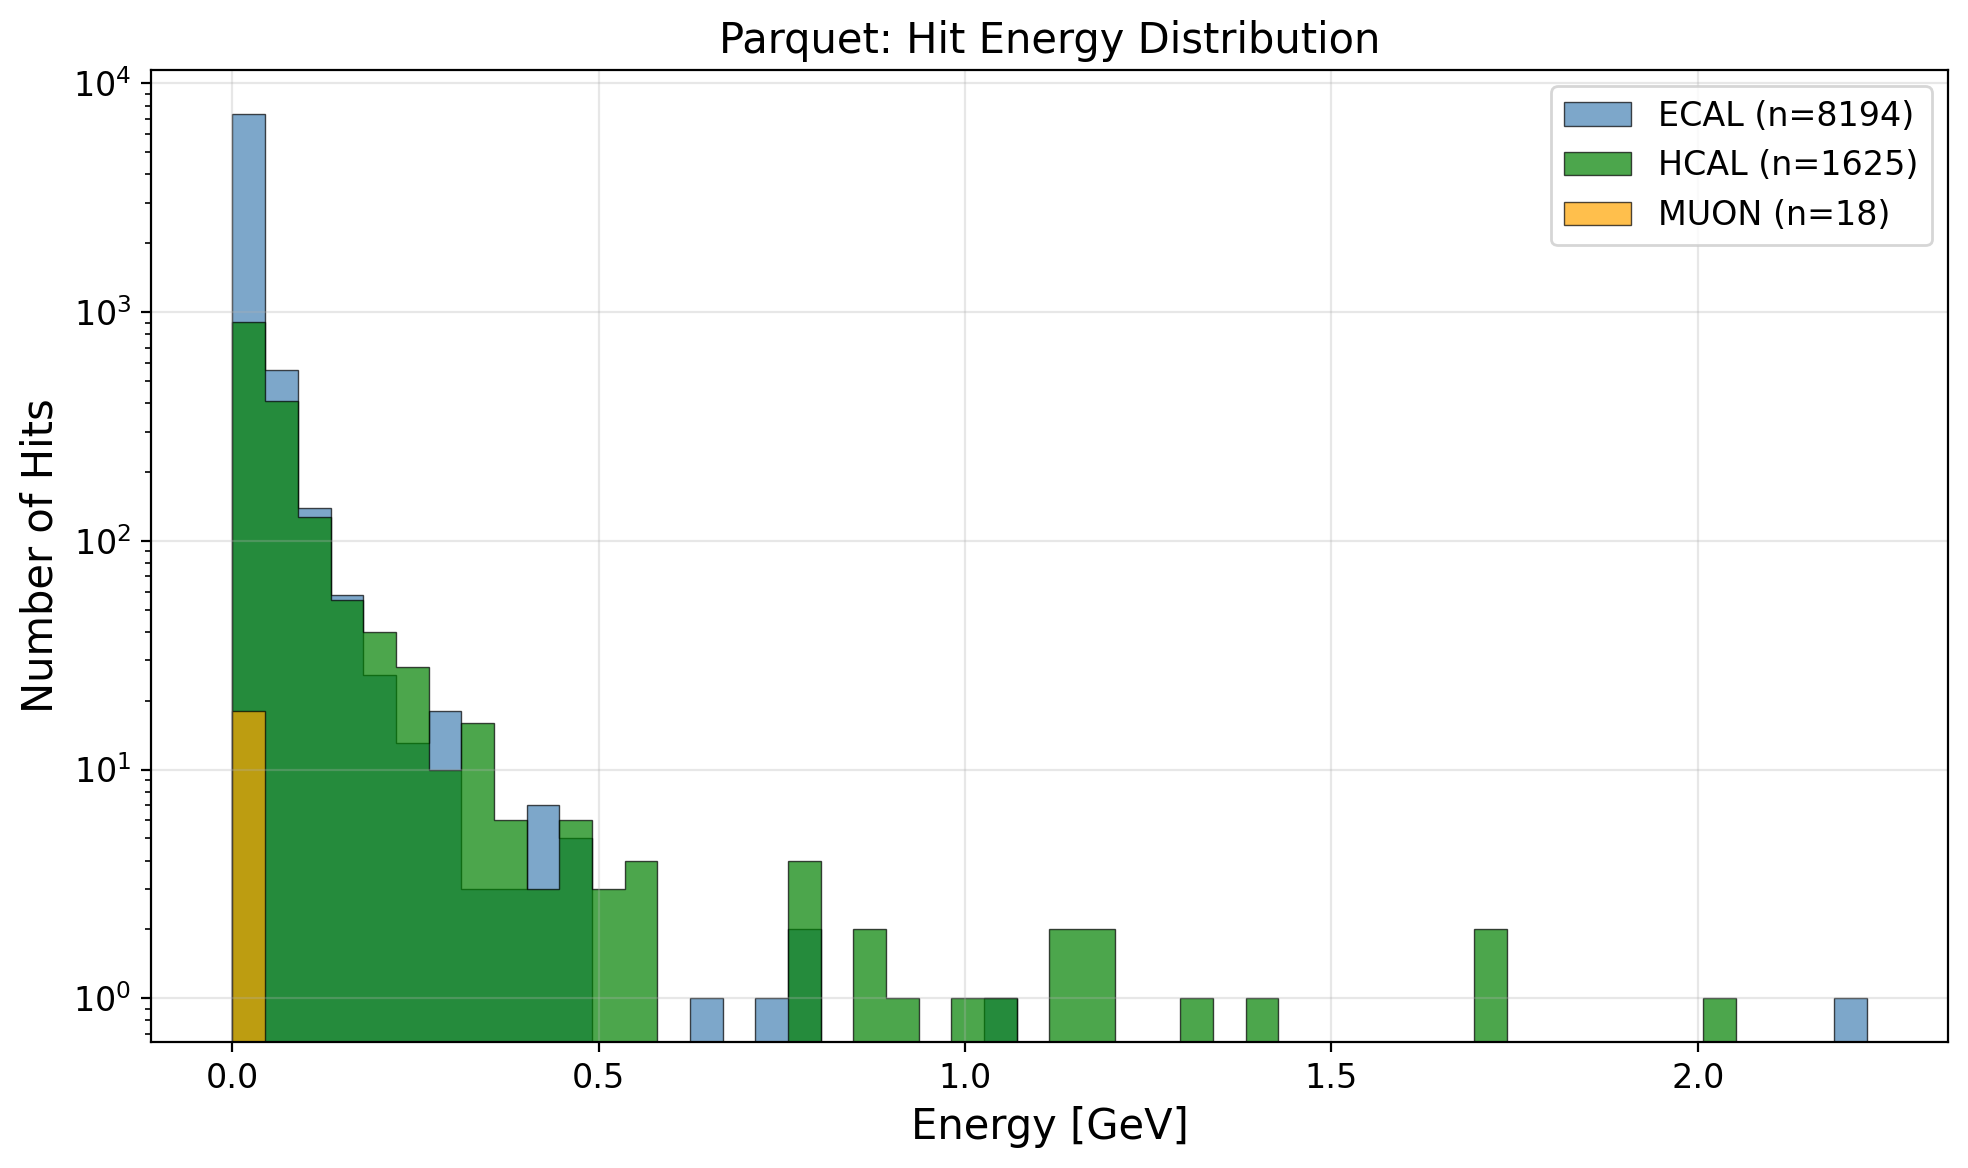

In [15]:
plot_energy_distribution(
    df_parquet,
    title_prefix="Parquet:",
    save_path=OUTPUT_DIR / f"parquet_energy_dist_event{EVENT_IDX}.png"
)

## Hit Count Statistics

Saved: plots/parquet_hit_counts_event0.png


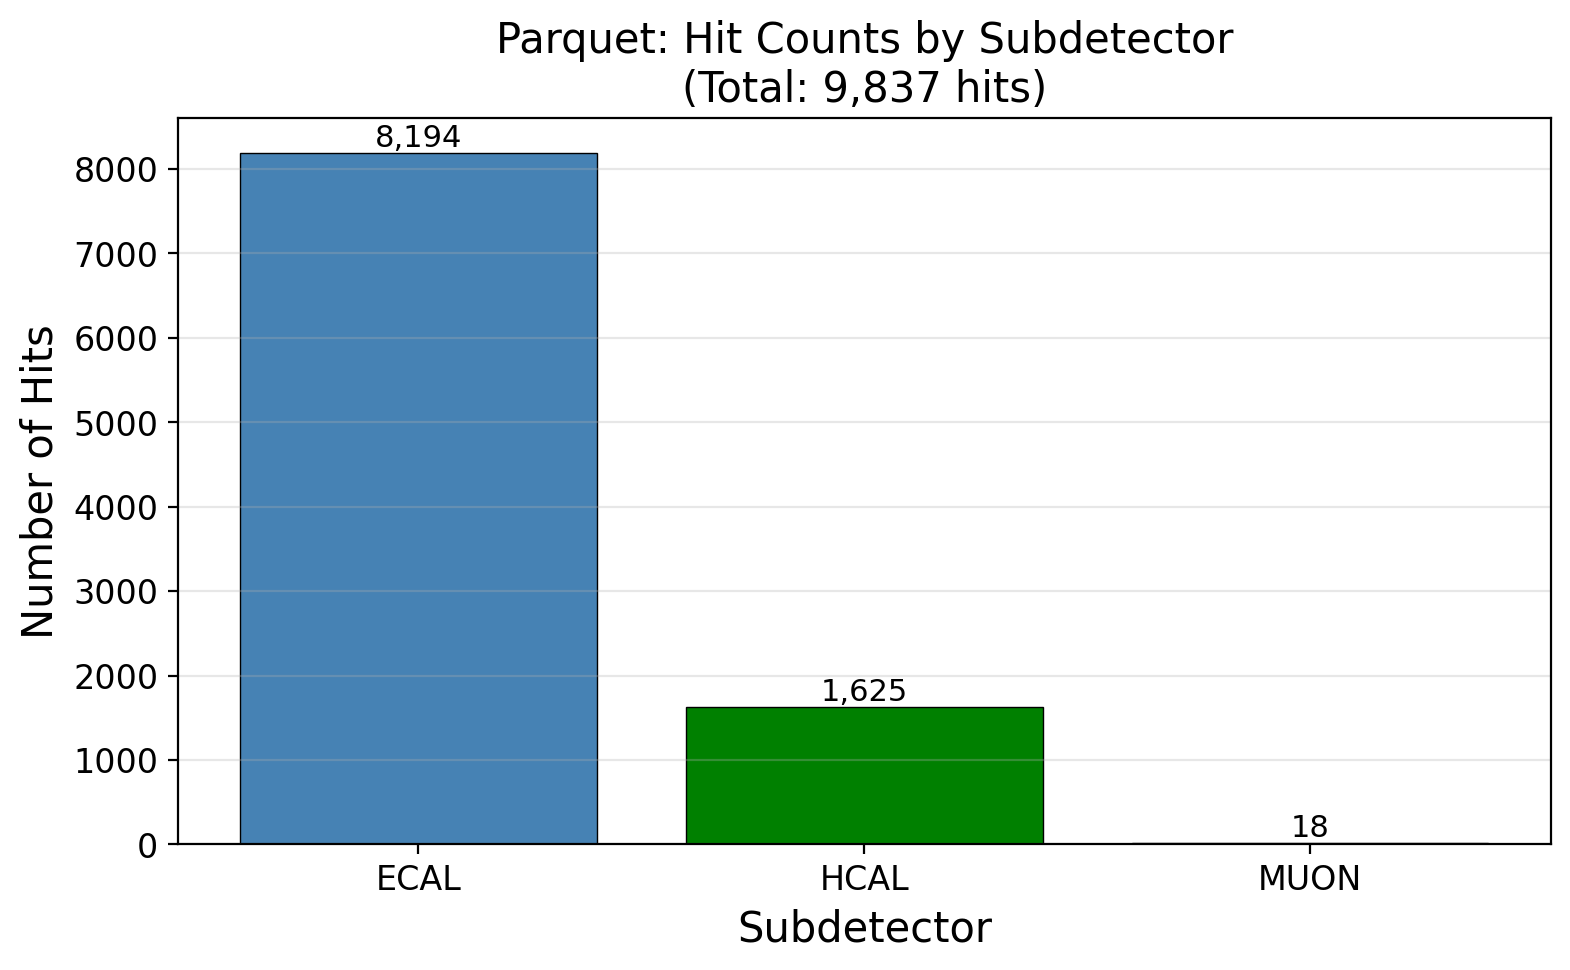

In [16]:
plot_hit_counts(
    df_parquet,
    title_prefix="Parquet:",
    save_path=OUTPUT_DIR / f"parquet_hit_counts_event{EVENT_IDX}.png"
)

---
# Data Comparison

In [17]:
# Compare hit counts between ROOT and Parquet
print("Hit Count Comparison (ROOT vs Parquet)")
print("=" * 40)

for subdet_code, label in SUBDETECTOR_LABELS.items():
    root_count = (df_root["subdetector"] == subdet_code).sum()
    parquet_count = (df_parquet["subdetector"] == subdet_code).sum()
    match = "OK" if root_count == parquet_count else "MISMATCH"
    print(f"{label:8s}: ROOT={root_count:6,}  Parquet={parquet_count:6,}  [{match}]")

print(f"{'TOTAL':8s}: ROOT={len(df_root):6,}  Parquet={len(df_parquet):6,}")

Hit Count Comparison (ROOT vs Parquet)
ECAL    : ROOT= 8,194  Parquet= 8,194  [OK]
HCAL    : ROOT= 1,625  Parquet= 1,625  [OK]
MUON    : ROOT=    18  Parquet=    18  [OK]
TOTAL   : ROOT= 9,837  Parquet= 9,837
